In [17]:
import numpy as np
import pandas as pd

from rnd_helper import *
from mot_helper import *

# Notation

$\boldsymbol{w}_i$ and ${r_i}$ are the points and weights for the first density

$\boldsymbol{v}_j$ and ${c_j}$ are the points and weights for the second density

V = $[\boldsymbol{v}_1, ..., \boldsymbol{v}_n]$

W = $[r_1\boldsymbol{w}_1, ..., r_n\boldsymbol{w}_n]$

PV = W

C is Cost Matrix

# Constants

In [18]:
RISK_FREE_RATE: float = 0.05

# Execution

In [19]:
all_options = pd.read_csv("/Users/nickhofstetter/Documents/ETH/Master/MT/NVDA_historical_data/NVDA_call_prices_210201.csv", index_col=0)
stock = pd.read_csv("/Users/nickhofstetter/Documents/ETH/Master/MT/NVDA_historical_data/NVDA_closing_prices.csv", index_col=0)

S0 = stock.loc['2021-02-01'].values[0]
all_options['spot_price'] = S0
all_options['fetch_date'] = '2021-02-01'
options = all_options[all_options['maturity'] == '19/02/2021']

option_data = all_options
option_data['best_ask'] = option_data['best_ask']/100
option_data['best_bid'] = option_data['best_bid']/100
print(f"Fetched {len(option_data)} option contracts.")
print(f"Spot Price: {option_data['spot_price'].iloc[0]:.2f}")

print("\nCalculating Implied Volatility (this may take a moment)...")
iv_results_df = calculate_iv_for_chain(option_data, r=RISK_FREE_RATE)

maturities = sorted(iv_results_df['time_to_maturity'].unique())

Fetched 594 option contracts.
Spot Price: 13.24

Calculating Implied Volatility (this may take a moment)...


In [ ]:
# ---------------------------------------------------------
# 1. Fit the entire volatility surface sequentially first
# ---------------------------------------------------------
K_fit_min, K_fit_max = 5, 25 # Set this slightly wider than your strike range
surface_params = fit_surface_svi(iv_results_df, S0, RISK_FREE_RATE, K_fit_min, K_fit_max)

# ---------------------------------------------------------
# 2. Maturities
# ---------------------------------------------------------
maturities = sorted(iv_results_df['time_to_maturity'].unique())
T1 = maturities[0]
T2 = maturities[1]

# ---------------------------------------------------------
# 3. Extract grids and probability masses
# ---------------------------------------------------------
K1, r_mass = extract_rnd_for_maturity_constrained(surface_params, T1, S0, RISK_FREE_RATE, n_points=402)
K2, c_mass = extract_rnd_for_maturity_constrained(surface_params, T2, S0, RISK_FREE_RATE, n_points=402)

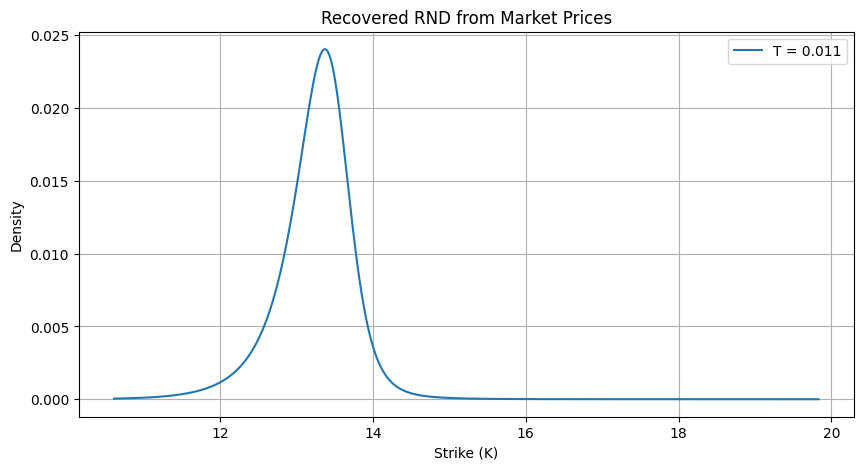

In [16]:
plt.figure(figsize=(10,5))
plt.plot(K1, r_mass, label=f"T = {T1:.3f}")
plt.legend()
plt.grid()
plt.ylabel("Density")
plt.xlabel("Strike (K)")
plt.title("Recovered RND from Market Prices")
plt.show()

In [8]:
def plot_svi_fit_comparison(iv_results_df, surface_params, T, S0, rate):
    """
    Plots a side-by-side comparison of True vs. SVI Implied Volatilities 
    and Call Prices for a specific maturity T.
    """
    df_T = iv_results_df[iv_results_df['time_to_maturity'] == T].sort_values(by='strike')
    
    K_true = df_T['strike'].values
    iv_true = df_T['ImpliedVolatility'].values
    
    if 'call_price' in df_T.columns:
        price_true = df_T['call_price'].values
    else:
        price_true = np.array([
            black_scholes_price(S0, k, T, rate, sig) 
            for k, sig in zip(K_true, iv_true)
        ])
        
    params = surface_params[T]
    K_dense = np.linspace(min(K_true) * 0.8, max(K_true) * 1.2, 200)
    
    iv_svi_dense = svi_iv_from_params(K_dense, params)
    price_svi_dense = np.array([
        black_scholes_price(S0, k, T, rate, sig) 
        for k, sig in zip(K_dense, iv_svi_dense)
    ])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].scatter(K_true, iv_true, color='dodgerblue', label='Market IV', marker='o', zorder=3)
    axes[0].plot(K_dense, iv_svi_dense, color='darkorange', label='SVI Fit', linewidth=2, zorder=2)
    axes[0].set_title(f'Implied Volatility Smile (T = {T:.3f})', fontsize=12)
    axes[0].set_xlabel('Strike (K)', fontsize=10)
    axes[0].set_ylabel('Implied Volatility', fontsize=10)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    axes[1].scatter(K_true, price_true, color='dodgerblue', label='Market Prices', marker='o', zorder=3)
    axes[1].plot(K_dense, price_svi_dense, color='darkorange', label='SVI Fit Prices', linewidth=2, zorder=2)
    axes[1].set_title(f'Call Option Prices (T = {T:.3f})', fontsize=12)
    axes[1].set_xlabel('Strike (K)', fontsize=10)
    axes[1].set_ylabel('Call Price', fontsize=10)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

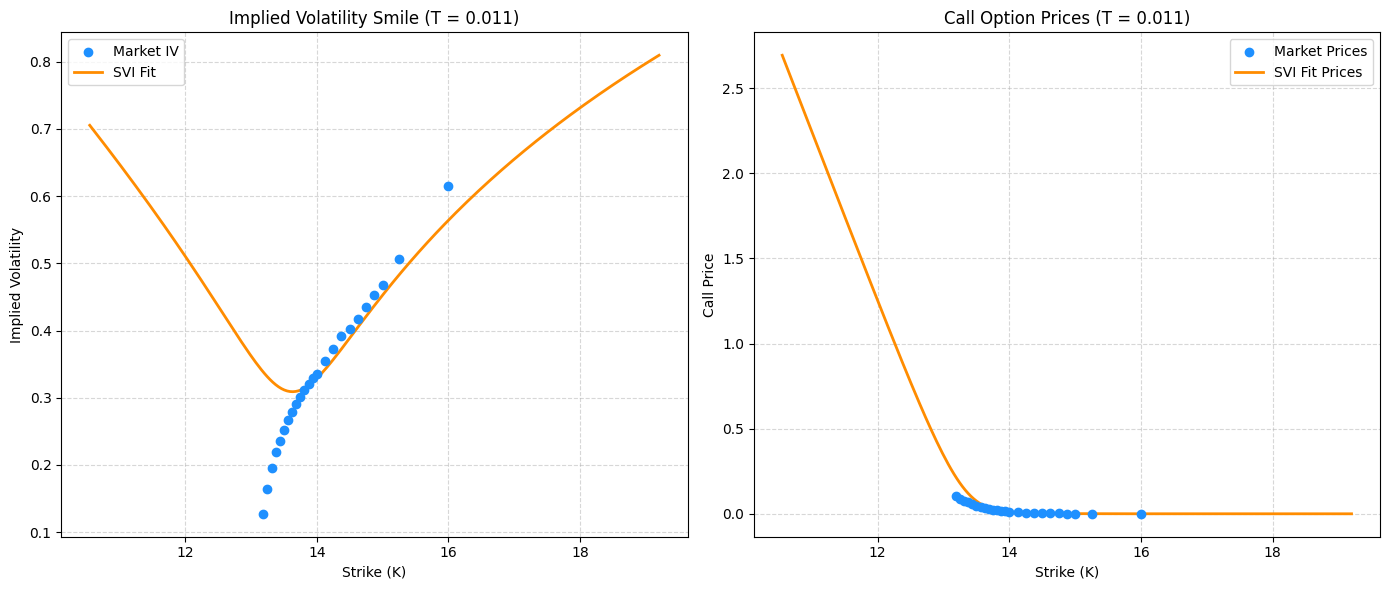

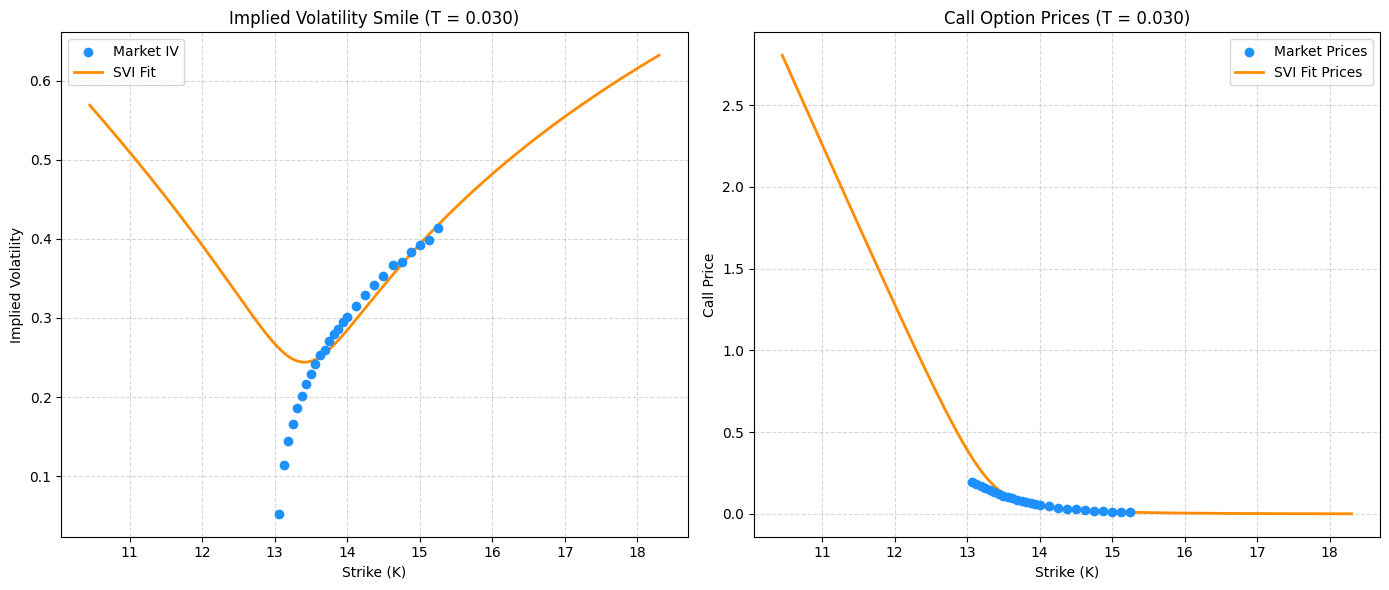

In [9]:
plot_svi_fit_comparison(iv_results_df, surface_params, T1, S0, RISK_FREE_RATE)
plot_svi_fit_comparison(iv_results_df, surface_params, T2, S0, RISK_FREE_RATE)